# Fusión RRNNs

## Celda 1 - Imports y configuración Global

In [1]:
# ============================================================
# CELDA 1 — Imports y Configuración del Entorno
# 05_ModeloMultimodal.ipynb | SmartHost Analytics
# ============================================================

# --- Librerías estándar ---
import os
import random
import numpy as np
import pandas as pd

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- PyTorch ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ============================================================
# CONFIGURACIÓN DEL DISPOSITIVO (GPU / MPS / CPU)
# ============================================================
print(f"Versión de PyTorch : {torch.__version__}")
print(f"CUDA disponible    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU detectada      : {torch.cuda.get_device_name(0)}")

device = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"\n✅ Usando dispositivo: {device.upper()}")

# ============================================================
# SEMILLA ALEATORIA — Reproducibilidad total
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print(f"✅ Semilla fijada: {SEED}")

# ============================================================
# CONSTANTES GLOBALES DEL PROYECTO
# ============================================================
TABULAR_DIM  = 35     # Columnas del modelo tabular
VISUAL_DIM   = 512    # Dimensiones del embedding ResNet34
FUSION_DIM   = TABULAR_DIM + VISUAL_DIM  # 547 inputs a la Super-Red

BATCH_SIZE   = 64
MAX_EPOCHS   = 500
LEARNING_RATE = 0.0005
PATIENCE      = 15    # Early Stopping

print(f"\n📐 Dimensiones del súper-vector de fusión: {TABULAR_DIM} + {VISUAL_DIM} = {FUSION_DIM}")
print(f"📦 Batch size: {BATCH_SIZE} | 🔁 Épocas máx: {MAX_EPOCHS} | 📉 LR: {LEARNING_RATE}")

Versión de PyTorch : 2.5.1
CUDA disponible    : True
GPU detectada      : NVIDIA GeForce RTX 4070 Laptop GPU

✅ Usando dispositivo: CUDA
✅ Semilla fijada: 42

📐 Dimensiones del súper-vector de fusión: 35 + 512 = 547
📦 Batch size: 64 | 🔁 Épocas máx: 500 | 📉 LR: 0.0005


## 2- Carga Tabular

In [2]:
# ============================================================
# CELDA 2 — Carga de Datos Tabulares
# ============================================================

# --- Carga del CSV limpio ---
df = pd.read_csv('../data/listingV5_PriceCapID.csv')

print("=" * 55)
print("📂 DATASET TABULAR CARGADO")
print("=" * 55)
print(f"Shape: {df.shape[0]} filas x {df.shape[1]} columnas")
# ============================================================
# VERIFICACIÓN DE COLUMNAS CLAVE
# ============================================================
columnas_requeridas = ['id', 'price']
for col in columnas_requeridas:
    estado = "✅" if col in df.columns else "❌ NO ENCONTRADA"
    print(f"  Columna '{col}': {estado}")

# ============================================================
# IDENTIFICAR FEATURES, TARGET E ID
# ============================================================
TARGET_COL  = 'price'
ID_COL      = 'id'

# Todas las columnas excepto id y price son features
feature_cols = [col for col in df.columns if col not in [ID_COL, TARGET_COL]]

print(f"\n📌 Variable objetivo  : '{TARGET_COL}'")
print(f"📌 Columna ID         : '{ID_COL}'")
print(f"📌 Nº de features     : {len(feature_cols)}")

# Advertencia si no cuadra con TABULAR_DIM definido en Celda 1
if len(feature_cols) != TABULAR_DIM:
    print(f"\n⚠️  AVISO: Se esperaban {TABULAR_DIM} features pero se encontraron {len(feature_cols)}.")
    print("   Revisa el CSV o ajusta TABULAR_DIM en la Celda 1.")
else:
    print(f"✅ Confirmado: {len(feature_cols)} features coinciden con TABULAR_DIM = {TABULAR_DIM}")

# ============================================================
# LISTADO DE FEATURES
# ============================================================
print(f"\n📋 Lista de features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:02d}. {col}")

# ============================================================
# ANÁLISIS RÁPIDO DE CALIDAD
# ============================================================
print("\n" + "=" * 55)
print("🔍 ANÁLISIS DE CALIDAD DEL DATASET")
print("=" * 55)

nulos = df.isnull().sum()
nulos_totales = nulos.sum()

if nulos_totales == 0:
    print("✅ Sin valores nulos.")
else:
    print(f"⚠️  Valores nulos detectados ({nulos_totales} total):")
    print(nulos[nulos > 0])

# Estadísticas del target
print(f"\n📊 Estadísticas de '{TARGET_COL}':")
print(f"   Media   : {df[TARGET_COL].mean():.2f} €")
print(f"   Mediana : {df[TARGET_COL].median():.2f} €")
print(f"   Mín     : {df[TARGET_COL].min():.2f} €")
print(f"   Máx     : {df[TARGET_COL].max():.2f} €")
print(f"   Std     : {df[TARGET_COL].std():.2f} €")

# Tipos de datos
print(f"\n🔢 Tipos de datos:")
print(df[feature_cols].dtypes.value_counts().to_string())

# ============================================================
# PREVIEW
# ============================================================
print("\n" + "=" * 55)
print("👀 PRIMERAS 3 FILAS (columnas clave):")
print("=" * 55)
print(df[[ID_COL, TARGET_COL] + feature_cols[:5]].head(3).to_string(index=False))

📂 DATASET TABULAR CARGADO
Shape: 5739 filas x 32 columnas
  Columna 'id': ✅
  Columna 'price': ✅

📌 Variable objetivo  : 'price'
📌 Columna ID         : 'id'
📌 Nº de features     : 30

⚠️  AVISO: Se esperaban 35 features pero se encontraron 30.
   Revisa el CSV o ajusta TABULAR_DIM en la Celda 1.

📋 Lista de features (30):
   01. host_response_time
   02. host_response_rate
   03. host_is_superhost
   04. longitude
   05. room_type
   06. accommodates
   07. bathrooms
   08. bedrooms
   09. beds
   10. number_of_reviews_ltm
   11. review_scores_rating
   12. review_scores_accuracy
   13. review_scores_cleanliness
   14. review_scores_location
   15. review_scores_value
   16. reviews_per_month
   17. private_bathroom
   18. has_cooking_basics
   19. has_tv
   20. has_air_conditioning
   21. has_washer
   22. has_heating
   23. has_freezer
   24. has_coffee_maker
   25. has_balcony_or_terrace
   26. distancia_centro_km
   27. personas_por_habitacion
   28. banos_por_huesped
   29. amenit

## 3. Carga datos CNN

In [3]:
# ============================================================
# CELDA 3 — Carga de Datos Visuales (ResNet34 Embeddings)
# ============================================================

# --- Carga de los archivos .npy ---
embeddings = np.load('../data/resnet34_embeddings.npy')
visual_ids  = np.load('../data/resnet34_ids.npy')

print("=" * 55)
print("🖼️  DATOS VISUALES CARGADOS")
print("=" * 55)

# ============================================================
# SHAPES Y TIPOS
# ============================================================
print(f"\n📐 embeddings shape : {embeddings.shape}")
print(f"   → {embeddings.shape[0]} apartamentos x {embeddings.shape[1]} dimensiones")
print(f"   → dtype           : {embeddings.dtype}")

print(f"\n🔑 visual_ids shape : {visual_ids.shape}")
print(f"   → dtype           : {visual_ids.dtype}")

# ============================================================
# VERIFICACIONES DE INTEGRIDAD
# ============================================================
print("\n" + "=" * 55)
print("🔍 VERIFICACIONES DE INTEGRIDAD")
print("=" * 55)

# 1. Nº de apartamentos debe coincidir entre ambos arrays
if embeddings.shape[0] == visual_ids.shape[0]:
    print(f"✅ Nº de registros alineados: {embeddings.shape[0]} en ambos arrays")
else:
    print(f"❌ DESAJUSTE: embeddings tiene {embeddings.shape[0]} filas "
            f"pero visual_ids tiene {visual_ids.shape[0]} filas.")

# 2. Dimensión visual debe coincidir con VISUAL_DIM de Celda 1
if embeddings.shape[1] == VISUAL_DIM:
    print(f"✅ Dimensión visual confirmada: {embeddings.shape[1]} == VISUAL_DIM = {VISUAL_DIM}")
else:
    print(f"⚠️  AVISO: Se esperaban {VISUAL_DIM} dimensiones pero el array tiene {embeddings.shape[1]}.")
    print(f"   Ajusta VISUAL_DIM en la Celda 1 a {embeddings.shape[1]}.")
    VISUAL_DIM   = embeddings.shape[1]
    FUSION_DIM   = TABULAR_DIM + VISUAL_DIM
    print(f"   🔧 VISUAL_DIM y FUSION_DIM actualizados automáticamente: {FUSION_DIM}")

# 3. Comprobar NaNs o Infs en los embeddings
nan_count = np.isnan(embeddings).sum()
inf_count = np.isinf(embeddings).sum()

if nan_count == 0 and inf_count == 0:
    print(f"✅ Sin NaNs ni Infs en los embeddings.")
else:
    print(f"⚠️  NaNs detectados: {nan_count} | Infs detectados: {inf_count}")
    print(f"   Revisa el script de extracción de embeddings antes de continuar.")

# 4. IDs únicos — no debe haber duplicados
ids_unicos = len(np.unique(visual_ids))
if ids_unicos == len(visual_ids):
    print(f"✅ Todos los IDs son únicos: {ids_unicos} IDs")
else:
    duplicados = len(visual_ids) - ids_unicos
    print(f"⚠️  IDs duplicados detectados: {duplicados}. Revisa el proceso de extracción.")

# ============================================================
# PREVIEW DE VALORES
# ============================================================
print("\n" + "=" * 55)
print("👀 PREVIEW")
print("=" * 55)
print(f"\n🔑 Primeros 5 IDs visuales  : {visual_ids[:5]}")
print(f"\n📊 Estadísticas del embedding (global):")
print(f"   Media global : {embeddings.mean():.6f}")
print(f"   Std global   : {embeddings.std():.6f}")
print(f"   Mín          : {embeddings.min():.6f}")
print(f"   Máx          : {embeddings.max():.6f}")

print(f"\n🔢 Primeros 10 valores del embedding del apartamento [0]:")
print(f"   {embeddings[0, :10]}")

# ============================================================
# CRUCE PRELIMINAR CON DATASET TABULAR (solo conteo)
# ============================================================
print("\n" + "=" * 55)
print("🔗 CRUCE PRELIMINAR CON DATASET TABULAR")
print("=" * 55)

ids_tabular = set(df[ID_COL].values)
ids_visual  = set(visual_ids)

ids_comunes    = ids_tabular & ids_visual
ids_solo_tab   = ids_tabular - ids_visual
ids_solo_visual = ids_visual - ids_tabular

print(f"   IDs en tabular          : {len(ids_tabular)}")
print(f"   IDs en visual           : {len(ids_visual)}")
print(f"   IDs comunes (merge)     : {len(ids_comunes)}  ← registros que entrarán al modelo")
print(f"   Solo en tabular (sin foto): {len(ids_solo_tab)}")
print(f"   Solo en visual (sin datos): {len(ids_solo_visual)}")

perdida_pct = (1 - len(ids_comunes) / len(ids_tabular)) * 100
print(f"\n   📉 Pérdida estimada por merge: {perdida_pct:.1f}% del dataset tabular")

if perdida_pct > 30:
    print(f"   ⚠️  Alta pérdida de datos. Revisa si el scraping de imágenes fue completo.")
else:
    print(f"   ✅ Pérdida aceptable para continuar.")

🖼️  DATOS VISUALES CARGADOS

📐 embeddings shape : (5667, 512)
   → 5667 apartamentos x 512 dimensiones
   → dtype           : float32

🔑 visual_ids shape : (5667,)
   → dtype           : int64

🔍 VERIFICACIONES DE INTEGRIDAD
✅ Nº de registros alineados: 5667 en ambos arrays
✅ Dimensión visual confirmada: 512 == VISUAL_DIM = 512
✅ Sin NaNs ni Infs en los embeddings.
✅ Todos los IDs son únicos: 5667 IDs

👀 PREVIEW

🔑 Primeros 5 IDs visuales  : [ 96033 166473 330760 340024 358541]

📊 Estadísticas del embedding (global):
   Media global : 0.903614
   Std global   : 0.715393
   Mín          : 0.000000
   Máx          : 14.190723

🔢 Primeros 10 valores del embedding del apartamento [0]:
   [2.0305195  0.7123366  0.6305843  0.51871145 1.3290305  1.425918
 2.0511012  0.44252717 2.44349    1.3408086 ]

🔗 CRUCE PRELIMINAR CON DATASET TABULAR
   IDs en tabular          : 5739
   IDs en visual           : 5667
   IDs comunes (merge)     : 2165  ← registros que entrarán al modelo
   Solo en tabular

## 4. Sincronización por ID

🖼️  DataFrame Visual construido
   Shape : (5667, 513)
   IDs únicos en visual: 5667

🔗 REALIZANDO INNER MERGE
   Filas en CSV tabular   : 5,739
   Imágenes disponibles   : 5,667
   Filas tras el merge    : 5,667  ← registros que entrarán al modelo
   Filas perdidas         : 72 (1.3%)

   ℹ️  La pérdida es ESPERADA: solo se descargaron ~2.165 imágenes
      del total de 5,739 listings del CSV original.
      El modelo multimodal entrena con los 5,667 que tienen ambos datos.

🔍 VERIFICACIONES POST-MERGE
   ⚠️  645 nulos. Aplicando dropna()...
   ✅ Nulos eliminados. Filas restantes: 5,265
   ✅ Sin IDs duplicados.

📋 ESTRUCTURA FINAL DE df_merged
   Columna ID          : 1  ('id')
   Columnas tabulares  : 30  (features del piso)
   Columnas visuales   : 512  (emb_0 ... emb_511)
   Columna target      : 1  ('price')
   TOTAL columnas      : 544

   ✅ FUSION_DIM = 30 + 512 = 542
   ✅ TABULAR_DIM actualizado a: 30


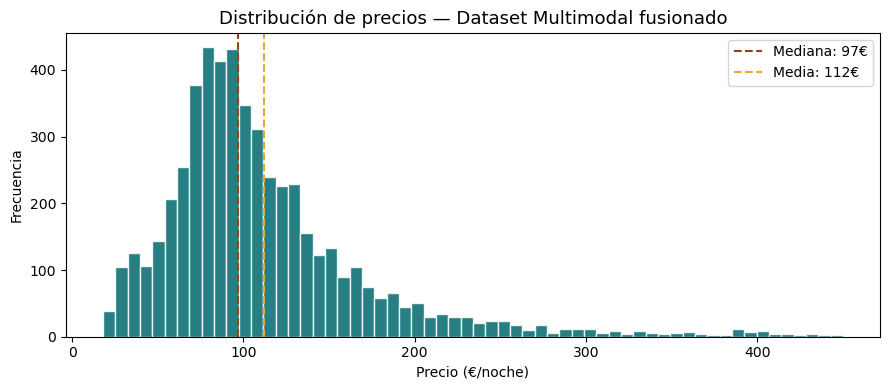


📊 Estadísticas de precio (dataset fusionado):
count    5265.00
mean      111.96
std        62.05
min        18.00
25%        75.00
50%        97.00
75%       132.00
max       450.00
Name: price, dtype: float64


In [4]:
# ============================================================
# CELDA 4 — Sincronización y Merge por ID (Paso Crítico)
# ============================================================



# ============================================================
# PASO 1: Construir DataFrame visual (IDs + embeddings)
# ============================================================
embedding_cols = [f'emb_{i}' for i in range(VISUAL_DIM)]

df_visual = pd.DataFrame(embeddings, columns=embedding_cols)
df_visual.insert(0, ID_COL, visual_ids)
df_visual[ID_COL] = df_visual[ID_COL].astype(np.int64)

# ── FIX IDs: normalizar ID en ambos DataFrames a int64 limpio ──
df[ID_COL]        = df[ID_COL].astype(float).astype(np.int64)
df_visual[ID_COL] = df_visual[ID_COL].astype(np.int64)   # ya debería ser int64, pero por seguridad

print("=" * 55)
print("🖼️  DataFrame Visual construido")
print("=" * 55)
print(f"   Shape : {df_visual.shape}")
print(f"   IDs únicos en visual: {df_visual[ID_COL].nunique()}")

# ============================================================
# PASO 2: INNER MERGE — Solo apartamentos con ambos datos
# ============================================================
print("\n" + "=" * 55)
print("🔗 REALIZANDO INNER MERGE")
print("=" * 55)

filas_antes = len(df)

df_merged = pd.merge(df, df_visual, on=ID_COL, how='inner')

filas_despues  = len(df_merged)
filas_perdidas = filas_antes - filas_despues
pct_perdida    = (filas_perdidas / filas_antes) * 100

print(f"   Filas en CSV tabular   : {filas_antes:,}")
print(f"   Imágenes disponibles   : {len(df_visual):,}")
print(f"   Filas tras el merge    : {filas_despues:,}  ← registros que entrarán al modelo")
print(f"   Filas perdidas         : {filas_perdidas:,} ({pct_perdida:.1f}%)")
print(f"\n   ℹ️  La pérdida es ESPERADA: solo se descargaron ~2.165 imágenes")
print(f"      del total de {filas_antes:,} listings del CSV original.")
print(f"      El modelo multimodal entrena con los {filas_despues:,} que tienen ambos datos.")

# ============================================================
# PASO 3: Verificar nulos y duplicados post-merge
# ============================================================
print("\n" + "=" * 55)
print("🔍 VERIFICACIONES POST-MERGE")
print("=" * 55)

total_nulos = df_merged.isnull().sum().sum()
if total_nulos == 0:
    print(f"   ✅ Sin valores nulos.")
else:
    print(f"   ⚠️  {total_nulos} nulos. Aplicando dropna()...")
    df_merged.dropna(inplace=True)
    df_merged.reset_index(drop=True, inplace=True)
    print(f"   ✅ Nulos eliminados. Filas restantes: {len(df_merged):,}")

duplicados = df_merged[ID_COL].duplicated().sum()
if duplicados == 0:
    print(f"   ✅ Sin IDs duplicados.")
else:
    print(f"   ⚠️  {duplicados} duplicados. Eliminando...")
    df_merged.drop_duplicates(subset=ID_COL, inplace=True)
    df_merged.reset_index(drop=True, inplace=True)

# ============================================================
# PASO 4: Confirmar estructura y actualizar FUSION_DIM
# ============================================================
print("\n" + "=" * 55)
print("📋 ESTRUCTURA FINAL DE df_merged")
print("=" * 55)

cols_tabular_en_merged = [c for c in feature_cols if c in df_merged.columns]
cols_visual_en_merged  = [c for c in embedding_cols if c in df_merged.columns]

TABULAR_DIM_REAL = len(cols_tabular_en_merged)
VISUAL_DIM_REAL  = len(cols_visual_en_merged)
FUSION_DIM       = TABULAR_DIM_REAL + VISUAL_DIM_REAL

# Actualizar TABULAR_DIM por si difería de la constante inicial
TABULAR_DIM = TABULAR_DIM_REAL

print(f"   Columna ID          : 1  ('{ID_COL}')")
print(f"   Columnas tabulares  : {TABULAR_DIM_REAL}  (features del piso)")
print(f"   Columnas visuales   : {VISUAL_DIM_REAL}  (emb_0 ... emb_{VISUAL_DIM_REAL - 1})")
print(f"   Columna target      : 1  ('{TARGET_COL}')")
print(f"   TOTAL columnas      : {df_merged.shape[1]}")
print(f"\n   ✅ FUSION_DIM = {TABULAR_DIM_REAL} + {VISUAL_DIM_REAL} = {FUSION_DIM}")
print(f"   ✅ TABULAR_DIM actualizado a: {TABULAR_DIM}")

# ============================================================
# PASO 5: Distribución de precio del dataset fusionado
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_merged[TARGET_COL], bins=60, color="#01696f", edgecolor="white", alpha=0.85)
ax.set_title("Distribución de precios — Dataset Multimodal fusionado", fontsize=13)
ax.set_xlabel("Precio (€/noche)")
ax.set_ylabel("Frecuencia")
ax.axvline(df_merged[TARGET_COL].median(), color="#964219", linestyle="--",
            label=f'Mediana: {df_merged[TARGET_COL].median():.0f}€')
ax.axvline(df_merged[TARGET_COL].mean(), color="#e8a838", linestyle="--",
            label=f'Media: {df_merged[TARGET_COL].mean():.0f}€')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de precio (dataset fusionado):")
print(df_merged[TARGET_COL].describe().round(2))

## 5. División target

In [5]:
# ============================================================
# CELDA 5 — Separación de features y target
# ============================================================

cols_tabular = [c for c in feature_cols if c in df_merged.columns]
# Detectar columnas visuales automáticamente:
# son todas las que no son tabulares, ni id, ni price
cols_visual = [c for c in df_merged.columns
                if c not in cols_tabular + [ID_COL, TARGET_COL]]

print(f"Columnas visuales detectadas: {len(cols_visual)}")  # debe ser 512
assert len(cols_visual) == VISUAL_DIM, \
    f"Se esperaban {VISUAL_DIM} columnas visuales, se encontraron {len(cols_visual)}"

# ── Encoding de columnas categóricas (string → int) ───────
# Identificar automáticamente las columnas object dentro de cols_tabular
cols_cat = df_merged[cols_tabular].select_dtypes(include="object").columns.tolist()

if cols_cat:
    print(f"⚙️  Columnas categóricas detectadas ({len(cols_cat)}): {cols_cat}")
    for col in cols_cat:
        df_merged[col] = pd.Categorical(df_merged[col]).codes
        # pd.Categorical.codes asigna -1 a NaN, 0,1,2... al resto
    print("✅ Encoding completado.\n")
else:
    print("✅ Sin columnas categóricas. No se requiere encoding.\n")

# ── Extracción ────────────────────────────────────────────
X_tabular = df_merged[cols_tabular].values.astype(np.float32)   # (N, 30)
X_visual  = df_merged[cols_visual].values.astype(np.float32)    # (N, 512)
y         = df_merged[TARGET_COL].values.astype(np.float32)     # (N,)

# ── Verificaciones ────────────────────────────────────────
print("=" * 55)
print("  FEATURES Y TARGET EXTRAÍDOS")
print("=" * 55)
print(f"  X_tabular  : {X_tabular.shape}  — dtype {X_tabular.dtype}")
print(f"  X_visual   : {X_visual.shape}  — dtype {X_visual.dtype}")
print(f"  y (target) : {y.shape}  — dtype {y.dtype}")
print()

assert X_tabular.shape[1] == TABULAR_DIM, \
    f"TABULAR_DIM desajustado: esperado {TABULAR_DIM}, obtenido {X_tabular.shape[1]}"
assert X_visual.shape[1] == VISUAL_DIM, \
    f"VISUAL_DIM desajustado: esperado {VISUAL_DIM}, obtenido {X_visual.shape[1]}"
assert X_tabular.shape[0] == X_visual.shape[0] == y.shape[0], \
    "Desajuste de filas entre X_tabular, X_visual e y"

print("✅ Dimensiones confirmadas:")
print(f"   TABULAR_DIM = {TABULAR_DIM}  → X_tabular cols OK")
print(f"   VISUAL_DIM  = {VISUAL_DIM} → X_visual cols OK")
print(f"   N muestras  = {y.shape[0]:,}")
print()

print("📊 Estadísticas de y (precio):")
print(f"   Media   : {y.mean():.2f} €")
print(f"   Mediana : {np.median(y):.2f} €")
print(f"   Std     : {y.std():.2f} €")
print(f"   Min/Max : {y.min():.0f} € / {y.max():.0f} €")

Columnas visuales detectadas: 512
⚙️  Columnas categóricas detectadas (2): ['host_response_time', 'room_type']
✅ Encoding completado.

  FEATURES Y TARGET EXTRAÍDOS
  X_tabular  : (5265, 30)  — dtype float32
  X_visual   : (5265, 512)  — dtype float32
  y (target) : (5265,)  — dtype float32

✅ Dimensiones confirmadas:
   TABULAR_DIM = 30  → X_tabular cols OK
   VISUAL_DIM  = 512 → X_visual cols OK
   N muestras  = 5,265

📊 Estadísticas de y (precio):
   Media   : 111.96 €
   Mediana : 97.00 €
   Std     : 62.04 €
   Min/Max : 18 € / 450 €


## 6. Escalado de features tabulares

In [6]:
# ============================================================
# CELDA 6 — Escalado de features tabulares
# ============================================================
# • StandardScaler solo sobre X_tabular
#   Los embeddings ResNet34 ya salen normalizados (ReLU + GlobalAvgPool)
#   → escalarlos de nuevo no aporta y puede distorsionar la geometría
# • Guardamos el scaler en disco para usarlo en inferencia
# ============================================================
import joblib
import pathlib

SCALER_PATH = pathlib.Path("../models/scaler_tabular.pkl")
SCALER_PATH.parent.mkdir(parents=True, exist_ok=True)

scaler = StandardScaler()
X_tabular_scaled = scaler.fit_transform(X_tabular)   # (5265, 30) float64
X_tabular_scaled = X_tabular_scaled.astype(np.float32)

# Persistir para inferencia futura
joblib.dump(scaler, SCALER_PATH)

# ── Verificaciones ────────────────────────────────────────
print("=" * 55)
print("  ESCALADO COMPLETADO")
print("=" * 55)
print(f"  X_tabular_scaled : {X_tabular_scaled.shape}  — dtype {X_tabular_scaled.dtype}")
print(f"  Scaler guardado  : {SCALER_PATH.resolve()}")
print()

# Comprobar que media ≈ 0 y std ≈ 1 por columna (media global)
print(f"  Media global tras escalar : {X_tabular_scaled.mean():.6f}  (esperado ≈ 0)")
print(f"  Std  global tras escalar  : {X_tabular_scaled.std():.6f}  (esperado ≈ 1)")
print()

# Columnas con std original = 0 (constantes) → el scaler las deja a 0, avisar
zero_var_cols = [cols_tabular[i] for i, s in enumerate(scaler.scale_) if s == 0]
if zero_var_cols:
    print(f"  ⚠️  Columnas con varianza cero (constantes): {zero_var_cols}")
    print("      → sus valores quedan a 0 tras escalar (inofensivo para la red)")
else:
    print("  ✅ Ninguna columna con varianza cero")

print()
print("  ✅ X_tabular_scaled listo para el Dataset de PyTorch")

  ESCALADO COMPLETADO
  X_tabular_scaled : (5265, 30)  — dtype float32
  Scaler guardado  : C:\Users\david\Desktop\ESP. IA - BD\PIA\TRABAJO_AIRBNB\SmartHost-Analytics\models\scaler_tabular.pkl

  Media global tras escalar : 0.000000  (esperado ≈ 0)
  Std  global tras escalar  : 1.000000  (esperado ≈ 1)

  ✅ Ninguna columna con varianza cero

  ✅ X_tabular_scaled listo para el Dataset de PyTorch


## 7. División train/val

In [7]:
# ============================================================
# CELDA 7 — Split Train / Test
# ============================================================
# • 80% train / 20% test
# • Split coordinado: mismo índice para tabular, visual e y
# • random_state=42 para reproducibilidad
# ============================================================

indices = np.arange(len(y))

idx_train, idx_test = train_test_split(
    indices,
    test_size=0.20,
    random_state=42
)

# Aplicar índices sobre los tres arrays
X_tab_train,  X_tab_test  = X_tabular_scaled[idx_train], X_tabular_scaled[idx_test]
X_vis_train,  X_vis_test  = X_visual[idx_train],         X_visual[idx_test]
y_train,      y_test       = y[idx_train],                y[idx_test]

# ── Verificaciones ────────────────────────────────────────
print("=" * 55)
print("  SPLIT TRAIN / TEST")
print("=" * 55)
print(f"  Total muestras : {len(y):,}")
print()
print(f"  TRAIN  ({len(y_train)/len(y)*100:.0f}%)  → {len(y_train):,} muestras")
print(f"    X_tab_train  : {X_tab_train.shape}")
print(f"    X_vis_train  : {X_vis_train.shape}")
print(f"    y_train      : {y_train.shape}")
print()
print(f"  TEST   ({len(y_test)/len(y)*100:.0f}%)  → {len(y_test):,} muestras")
print(f"    X_tab_test   : {X_tab_test.shape}")
print(f"    X_vis_test   : {X_vis_test.shape}")
print(f"    y_test       : {y_test.shape}")
print()

# Comprobar que no hay solapamiento de índices
assert len(set(idx_train) & set(idx_test)) == 0, "❌ Solapamiento entre train y test"
assert len(idx_train) + len(idx_test) == len(y),  "❌ Pérdida de muestras en el split"
print("  ✅ Sin solapamiento train/test")
print("  ✅ Suma de particiones = total de muestras")
print()

# Distribución del target en cada partición
print("📊 Distribución de precio (y):")
print(f"  {'Partición':<10} {'Media':>8} {'Mediana':>9} {'Std':>8} {'Min':>6} {'Max':>6}")
print(f"  {'-'*47}")
for nombre, arr in [("Train", y_train), ("Test", y_test), ("Global", y)]:
    print(f"  {nombre:<10} {arr.mean():>7.1f}€ {np.median(arr):>8.1f}€"
            f" {arr.std():>7.1f}€ {arr.min():>5.0f}€ {arr.max():>5.0f}€")

  SPLIT TRAIN / TEST
  Total muestras : 5,265

  TRAIN  (80%)  → 4,212 muestras
    X_tab_train  : (4212, 30)
    X_vis_train  : (4212, 512)
    y_train      : (4212,)

  TEST   (20%)  → 1,053 muestras
    X_tab_test   : (1053, 30)
    X_vis_test   : (1053, 512)
    y_test       : (1053,)

  ✅ Sin solapamiento train/test
  ✅ Suma de particiones = total de muestras

📊 Distribución de precio (y):
  Partición     Media   Mediana      Std    Min    Max
  -----------------------------------------------
  Train        112.2€     97.0€    61.9€    18€   450€
  Test         111.2€     97.0€    62.6€    20€   450€
  Global       112.0€     97.0€    62.0€    18€   450€


## 8. Clase multimodal

In [8]:
# ============================================================
# CELDA 8 — MultimodalDataset + DataLoaders
# ============================================================

class MultimodalDataset(Dataset):
    """
    Dataset que combina features tabulares + embeddings visuales.
    
    Args:
        tab  : np.ndarray (N, TABULAR_DIM) — features del piso escaladas
        vis  : np.ndarray (N, VISUAL_DIM)  — embeddings ResNet34
        labels: np.ndarray (N,)            — precio normalizado o raw
    """
    def __init__(self, tab: np.ndarray, vis: np.ndarray, labels: np.ndarray):
        self.tab    = torch.from_numpy(tab)
        self.vis    = torch.from_numpy(vis)
        self.labels = torch.from_numpy(labels)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        return self.tab[idx], self.vis[idx], self.labels[idx]


# ── Instanciar datasets ───────────────────────────────────
ds_train = MultimodalDataset(X_tab_train, X_vis_train, y_train)
ds_test  = MultimodalDataset(X_tab_test,  X_vis_test,  y_test)

# ── DataLoaders ───────────────────────────────────────────
dl_train = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,       # 0 = sin multiprocessing (seguro en Windows/Jupyter)
    pin_memory=True,     # acelera la transferencia CPU → GPU
    drop_last=True,      # descarta el último batch si es menor que BATCH_SIZE
)

dl_test = DataLoader(
    ds_test,
    batch_size=BATCH_SIZE,
    shuffle=False,       # test nunca se mezcla
    num_workers=0,
    pin_memory=True,
    drop_last=False,     # en test queremos evaluar todas las muestras
)

# ── Verificaciones ────────────────────────────────────────
print("=" * 55)
print("  DATASET Y DATALOADERS CREADOS")
print("=" * 55)
print(f"  ds_train  : {len(ds_train):,} muestras")
print(f"  ds_test   : {len(ds_test):,} muestras")
print()
print(f"  dl_train  : {len(dl_train):,} batches × batch_size={BATCH_SIZE}"
        f"  (drop_last=True)")
print(f"  dl_test   : {len(dl_test):,} batches × batch_size={BATCH_SIZE}"
        f"  (drop_last=False)")
print()

# Inspeccionar un batch real
tab_b, vis_b, y_b = next(iter(dl_train))
print("  🔍 Shapes de un batch de train:")
print(f"     tab_batch  : {tuple(tab_b.shape)}  dtype={tab_b.dtype}")
print(f"     vis_batch  : {tuple(vis_b.shape)}  dtype={vis_b.dtype}")
print(f"     y_batch    : {tuple(y_b.shape)}   dtype={y_b.dtype}")
print()
print(f"  ✅ FUSION_DIM confirmado: {tab_b.shape[1]} + {vis_b.shape[1]}"
        f" = {tab_b.shape[1] + vis_b.shape[1]}  (esperado {FUSION_DIM})")

  DATASET Y DATALOADERS CREADOS
  ds_train  : 4,212 muestras
  ds_test   : 1,053 muestras

  dl_train  : 65 batches × batch_size=64  (drop_last=True)
  dl_test   : 17 batches × batch_size=64  (drop_last=False)

  🔍 Shapes de un batch de train:
     tab_batch  : (64, 30)  dtype=torch.float32
     vis_batch  : (64, 512)  dtype=torch.float32
     y_batch    : (64,)   dtype=torch.float32

  ✅ FUSION_DIM confirmado: 30 + 512 = 542  (esperado 542)


## 9. Arquitectura RRNN multimodal

In [9]:
# ============================================================
# CELDA 9 — Arquitectura MultimodalMLP (Super-Red de Fusión)
# ============================================================

class MultimodalMLP(nn.Module):
    """
    Red de fusión multimodal tabular + visual.

    Recibe el súper-vector [tab ‖ vis] de dimensión FUSION_DIM
    y regresiona el precio del apartamento.

    Arquitectura:
        FUSION_DIM → 256 → 128 → 32 → 1
    """
    def __init__(self, fusion_dim: int):
        super().__init__()

        self.net = nn.Sequential(
            # Bloque 1
            nn.Linear(fusion_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Bloque 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Bloque 3
            nn.Linear(128, 32),
            nn.ReLU(),

            # Salida — lineal (regresión de precio)
            nn.Linear(32, 1),
        )

    def forward(self, tab: torch.Tensor, vis: torch.Tensor) -> torch.Tensor:
        """
        Args:
            tab : (B, TABULAR_DIM) — features tabulares escaladas
            vis : (B, VISUAL_DIM)  — embeddings ResNet34
        Returns:
            (B, 1) — precio predicho
        """
        x = torch.cat([tab, vis], dim=1)   # (B, FUSION_DIM)
        return self.net(x)                 # (B, 1)


# ── Instanciar y mover a GPU ──────────────────────────────
model = MultimodalMLP(fusion_dim=FUSION_DIM).to(device)

# ── Resumen del modelo ────────────────────────────────────
print("=" * 55)
print("  ARQUITECTURA MultimodalMLP")
print("=" * 55)
print(model)
print()

# Conteo de parámetros
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 55)
print("  PARÁMETROS DEL MODELO")
print("=" * 55)
print(f"  Entrada (FUSION_DIM)    : {FUSION_DIM}  ({TABULAR_DIM} tab + {VISUAL_DIM} vis)")
print(f"  Total parámetros        : {total_params:,}")
print(f"  Parámetros entrenables  : {trainable_params:,}")
print(f"  Dispositivo             : {next(model.parameters()).device}")
print()

# Smoke-test: forward pass con un batch sintético
with torch.no_grad():
    tab_dummy = torch.zeros(BATCH_SIZE, TABULAR_DIM, device=device)
    vis_dummy = torch.zeros(BATCH_SIZE, VISUAL_DIM,  device=device)
    out = model(tab_dummy, vis_dummy)

print(f"  🔍 Smoke-test forward:")
print(f"     Input  tab : {tuple(tab_dummy.shape)}")
print(f"     Input  vis : {tuple(vis_dummy.shape)}")
print(f"     Output     : {tuple(out.shape)}  ✅")

  ARQUITECTURA MultimodalMLP
MultimodalMLP(
  (net): Sequential(
    (0): Linear(in_features=542, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

  PARÁMETROS DEL MODELO
  Entrada (FUSION_DIM)    : 542  (30 tab + 512 vis)
  Total parámetros        : 176,833
  Parámetros entrenables  : 176,833
  Dispositivo             : cuda:0

  🔍 Smoke-test forward:
     Input  tab : (64, 30)
     Input  vis : (64, 512)
     Output     : (64, 1)  ✅


## 10. Configuración entrenamiento

In [10]:
# ============================================================
# CELDA 10 — Configuración del entrenamiento
# ============================================================

# ── Función de pérdida ────────────────────────────────────
criterion = nn.MSELoss()

# ── Optimizador ───────────────────────────────────────────
# Añadimos weight_decay para regularización L2 y evitar overfitting (desestimado tras pruebas)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    #weight_decay=1e-4    # L2 regularization
)

# ── Scheduler ─────────────────────────────────────────────
# Reduce LR × 0.5 si val_loss no mejora en 5 épocas consecutivas
# min_lr evita que el LR caiga a cero
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=True,
)

# ── Early Stopping (clase auxiliar) ──────────────────────
class EarlyStopping:
    """
    Para el entrenamiento si val_loss no mejora en `patience` épocas.
    Guarda el mejor modelo en disco automáticamente.
    """
    def __init__(self, patience: int = PATIENCE, path: str = "../models/best_multimodal.pt"):
        self.patience   = patience
        self.path       = pathlib.Path(path)
        self.path.parent.mkdir(parents=True, exist_ok=True)
        self.best_loss  = float("inf")
        self.counter    = 0
        self.best_epoch = 0
        self.stop       = False

    def step(self, val_loss: float, model: nn.Module, epoch: int) -> None:
        if val_loss < self.best_loss:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_epoch = epoch
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early_stopping = EarlyStopping(patience=PATIENCE)

# ── Resumen de configuración ──────────────────────────────
print("=" * 55)
print("  CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 55)
print(f"  Dispositivo      : {device}")
print(f"  Épocas máx.      : {MAX_EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print()
print(f"  Optimizador      : Adam  —  lr={LEARNING_RATE}")
print(f"  Loss             : MSELoss")
print()
print(f"  Scheduler        : ReduceLROnPlateau")
print(f"    mode           : min  (monitoriza val_loss)")
print(f"    factor         : 0.5  (LR × 0.5 al activarse)")
print(f"    patience       : 5 épocas")
print(f"    min_lr         : 1e-6")
print()
print(f"  Early Stopping   : patience={PATIENCE} épocas")
print(f"  Mejor modelo     : {early_stopping.path.resolve()}")
print()
print("  ✅ Listo para iniciar el bucle de entrenamiento")

  CONFIGURACIÓN DEL ENTRENAMIENTO
  Dispositivo      : cuda
  Épocas máx.      : 500
  Batch size       : 64

  Optimizador      : Adam  —  lr=0.0005
  Loss             : MSELoss

  Scheduler        : ReduceLROnPlateau
    mode           : min  (monitoriza val_loss)
    factor         : 0.5  (LR × 0.5 al activarse)
    patience       : 5 épocas
    min_lr         : 1e-6

  Early Stopping   : patience=15 épocas
  Mejor modelo     : C:\Users\david\Desktop\ESP. IA - BD\PIA\TRABAJO_AIRBNB\SmartHost-Analytics\models\best_multimodal.pt

  ✅ Listo para iniciar el bucle de entrenamiento


c:\Users\david\anaconda3\envs\Airbnb_PIA\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 11. Entrenamiento

In [11]:
# ============================================================
# CELDA 11 — Bucle de entrenamiento (versión completa)
# ============================================================
import time
from tqdm.auto import tqdm

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_mse = total_mae = 0.0

    for tab_b, vis_b, y_b in loader:
        tab_b, vis_b, y_b = tab_b.to(device), vis_b.to(device), y_b.to(device)

        optimizer.zero_grad()
        preds = model(tab_b, vis_b).squeeze(1)
        loss  = criterion(preds, y_b)
        loss.backward()
        optimizer.step()

        total_mse += loss.item()            * len(y_b)
        total_mae += (preds - y_b).abs().mean().item() * len(y_b)

    n = len(loader.dataset)
    return total_mse / n, total_mae / n


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_mse = total_mae = 0.0
    all_preds, all_y = [], []

    with torch.no_grad():
        for tab_b, vis_b, y_b in loader:
            tab_b, vis_b, y_b = tab_b.to(device), vis_b.to(device), y_b.to(device)

            preds = model(tab_b, vis_b).squeeze(1)
            total_mse += criterion(preds, y_b).item()   * len(y_b)
            total_mae += (preds - y_b).abs().mean().item() * len(y_b)
            all_preds.append(preds.cpu())
            all_y.append(y_b.cpu())

    n          = len(loader.dataset)
    mse        = total_mse / n
    mae        = total_mae / n
    rmse       = mse ** 0.5
    all_preds  = torch.cat(all_preds)
    all_y      = torch.cat(all_y)
    ss_res     = ((all_y - all_preds) ** 2).sum().item()
    ss_tot     = ((all_y - all_y.mean()) ** 2).sum().item()
    r2         = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    return mse, mae, rmse, r2


# ── Historial ─────────────────────────────────────────────
history = {k: [] for k in ("tr_mse", "tr_mae", "va_mse", "va_mae", "va_rmse", "r2", "lr")}

# ── Cabecera ──────────────────────────────────────────────
header = (f"{'Ep':>4} | {'Tr.MSE':>8} | {'Tr.MAE':>8} | "
          f"{'Va.MSE':>8} | {'Va.MAE':>8} | {'Va.RMSE':>8} | "
          f"{'R²':>6} | {'LR':>8} | Estado")
print(header)
print("-" * len(header))

t_start = time.time()

for epoch in tqdm(range(1, MAX_EPOCHS + 1), desc="Entrenando", unit="época"):

    # ── Train / Val ───────────────────────────────────────
    tr_mse, tr_mae             = train_epoch(model, dl_train, criterion, optimizer, device)
    va_mse, va_mae, va_rmse, r2 = eval_epoch(model, dl_test,  criterion, device)

    # ── Scheduler ─────────────────────────────────────────
    scheduler.step(va_mae)
    current_lr = optimizer.param_groups[0]["lr"]

    # ── Early Stopping ────────────────────────────────────
    early_stopping.step(va_mae, model, epoch)
    icon = "✅ Mejor" if early_stopping.counter == 0 else f"⏳ {early_stopping.counter}/{PATIENCE}"

    # ── Historial ─────────────────────────────────────────
    for k, v in zip(history, [tr_mse, tr_mae, va_mse, va_mae, va_rmse, r2, current_lr]):
        history[k].append(v)

    # ── Log ───────────────────────────────────────────────
    if epoch % 5 == 0 or epoch == 1 or early_stopping.stop:
        tqdm.write(
            f"{epoch:>4} | {tr_mse:>8.1f} | {tr_mae:>7.2f}€ | "
            f"{va_mse:>8.1f} | {va_mae:>7.2f}€ | {va_rmse:>7.2f}€ | "
            f"{r2:>6.3f} | {current_lr:>8.2e} | {icon}"
        )

    if early_stopping.stop:
        tqdm.write(f"\n🛑  Early Stopping en época {epoch} — mejor Val MAE: {early_stopping.best_loss:.2f}€")
        break

# ── Restaurar mejores pesos ───────────────────────────────
model.load_state_dict(torch.load(early_stopping.path, map_location=device))
model.eval()

best_ep  = history["va_mae"].index(min(history["va_mae"])) + 1
best_r2  = history["r2"][best_ep - 1]
best_tr  = history["tr_mae"][best_ep - 1]
elapsed  = time.time() - t_start

print(f"\n✅  Pesos del mejor modelo restaurados (época {best_ep})")
print(f"   Val MAE  = {min(history['va_mae']):.2f}€  |  "
      f"Train MAE = {best_tr:.2f}€  |  "
      f"Val R²    = {best_r2:.3f}")
print(f"   Tiempo total de entrenamiento: {elapsed / 60:.1f} min")

c:\Users\david\anaconda3\envs\Airbnb_PIA\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Ep |   Tr.MSE |   Tr.MAE |   Va.MSE |   Va.MAE |  Va.RMSE |     R² |       LR | Estado
----------------------------------------------------------------------------------------


Entrenando:   0%|          | 1/500 [00:00<02:54,  2.86época/s]

   1 |  15673.9 |  109.20€ |  15111.3 |  107.97€ |  122.93€ | -2.852 | 5.00e-04 | ✅ Mejor


Entrenando:   1%|          | 5/500 [00:01<02:23,  3.44época/s]

...

Entrenando:   9%|▉         | 45/500 [00:13<02:05,  3.62época/s]

  45 |    321.4 |   13.39€ |   1255.2 |   21.99€ |   35.43€ |  0.680 | 6.25e-05 | ⏳ 10/15


Entrenando:  10%|▉         | 49/500 [00:14<02:15,  3.32época/s]

  50 |    318.2 |   13.29€ |   1254.8 |   21.80€ |   35.42€ |  0.680 | 3.13e-05 | ⏳ 15/15

🛑  Early Stopping en época 50 — mejor Val MAE: 21.47€

✅  Pesos del mejor modelo restaurados (época 35)
   Val MAE  = 21.47€  |  Train MAE = 13.48€  |  Val R²    = 0.692
   Tiempo total de entrenamiento: 0.2 min



C:\Users\david\AppData\Local\Temp\ipykernel_31352\2327445097.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(early_stopping.path, map_

Tras varias pruebas modificando valores como el dropout, weight decay e incluso tamaño de la RRNN se obtuvieron los siguientes resultados:

| Config                        | Val MAE | Train MAE | Gap   | R²    | Veredicto                       |
| ----------------------------- | ------- | --------- | ----- | ----- | ------------------------------- |
| Original (D=0.3/0.2, WD=0)    | 21.47€  | 13.48€    | 7.99€ | 0.692 | Mejor métrica, overfitting alto |
| Opt 1+2 (D=0.5/0.4, WD=1e-3)  | 22.56€  | 18.63€    | 3.93€ | 0.672 | Mejor gap, peor MAE             |
| Opt 3 (arch pequeña, WD=1e-3) | 22.73€  | 17.81€    | 4.92€ | 0.683 | Equilibrado                     |
| Opt 3 + WD=1e-4               | 22.81€  | 19.73€    | 3.08€ | 0.659 | Menor gap, peor todo lo demás   |

**(Resultados sujetos a pequeños cambios en diferentes ejecuciones)**

Finalmente se opta por la configuración incial, aunque presenta mayor gap entre val y train, por tanto, mayor overfitting 

## 12. Gráfica Val/train

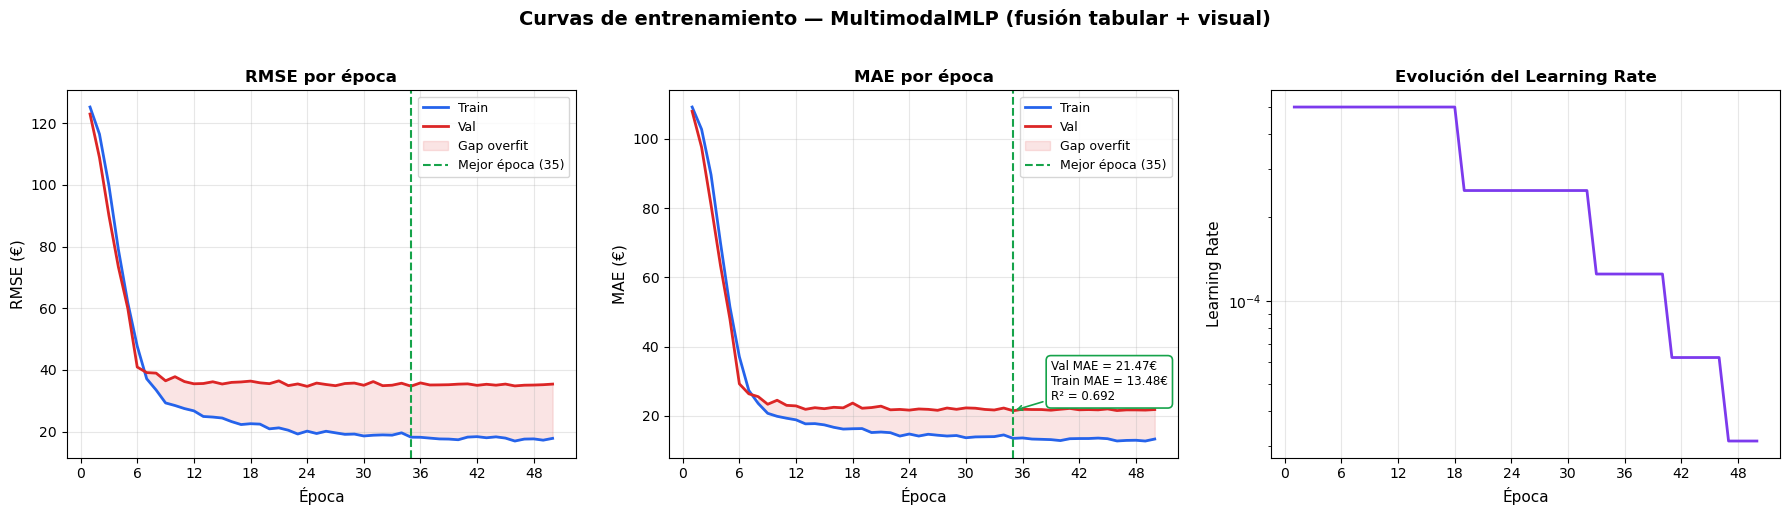

✅ Gráfica guardada en training_curves_multimodal.png


In [12]:
# ============================================================
# CELDA 12 — Visualización del entrenamiento
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

best_ep = history["va_mae"].index(min(history["va_mae"])) + 1

epochs     = range(1, len(history["tr_mse"]) + 1)
tr_rmse    = [v ** 0.5 for v in history["tr_mse"]]
va_rmse    = history["va_rmse"]
tr_mae     = history["tr_mae"]
va_mae     = history["va_mae"]
lr_hist    = history["lr"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Curvas de entrenamiento — MultimodalMLP (fusión tabular + visual)",
             fontsize=14, fontweight="bold", y=1.02)

# ── Paleta ────────────────────────────────────────────────
C_TRAIN  = "#2563EB"   # azul
C_VAL    = "#DC2626"   # rojo
C_BEST   = "#16A34A"   # verde
C_FILL   = "#DBEAFE"   # azul claro (relleno train)
C_FILL_V = "#FEE2E2"   # rojo claro (relleno val)

def plot_metric(ax, tr, va, ylabel, title):
    ax.plot(epochs, tr, color=C_TRAIN, lw=2,   label="Train")
    ax.plot(epochs, va, color=C_VAL,   lw=2,   label="Val")
    ax.fill_between(epochs, tr, va,
                    where=[v > t for t, v in zip(tr, va)],
                    alpha=0.12, color=C_VAL, label="Gap overfit")
    ax.axvline(best_ep, color=C_BEST, lw=1.5,
               linestyle="--", label=f"Mejor época ({best_ep})")
    ax.set_xlabel("Época", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ── Panel 1: RMSE ─────────────────────────────────────────
plot_metric(axes[0], tr_rmse, va_rmse,
            ylabel="RMSE (€)",
            title="RMSE por época")

# ── Panel 2: MAE ──────────────────────────────────────────
plot_metric(axes[1], tr_mae, va_mae,
            ylabel="MAE (€)",
            title="MAE por época")

# ── Panel 3: Learning Rate ────────────────────────────────
axes[2].plot(epochs, lr_hist, color="#7C3AED", lw=2)
axes[2].set_xlabel("Época", fontsize=11)
axes[2].set_ylabel("Learning Rate", fontsize=11)
axes[2].set_title("Evolución del Learning Rate", fontsize=12, fontweight="bold")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ── Anotación resumen en panel MAE ────────────────────────
best_va_mae = min(history["va_mae"])
best_tr_mae = history["tr_mae"][best_ep - 1]
best_r2     = history["r2"][best_ep - 1]

axes[1].annotate(
    f"Val MAE = {best_va_mae:.2f}€\nTrain MAE = {best_tr_mae:.2f}€\nR² = {best_r2:.3f}",
    xy=(best_ep, best_va_mae),
    xytext=(best_ep + max(2, len(list(epochs)) * 0.08), best_va_mae + 3),
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=C_BEST, lw=1.2),
    arrowprops=dict(arrowstyle="->", color=C_BEST, lw=1.2),
)

plt.tight_layout()
plt.savefig("training_curves_multimodal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfica guardada en training_curves_multimodal.png")

## 13. Análisis residuos

  MÉTRICAS FINALES — TEST SET
  MAE   : 21.47 €
  RMSE  : 34.75 €
  R²    : 0.6922
  Bias  : 3.4760 €  (esperado ≈ 0)
  N test: 1,053 muestras


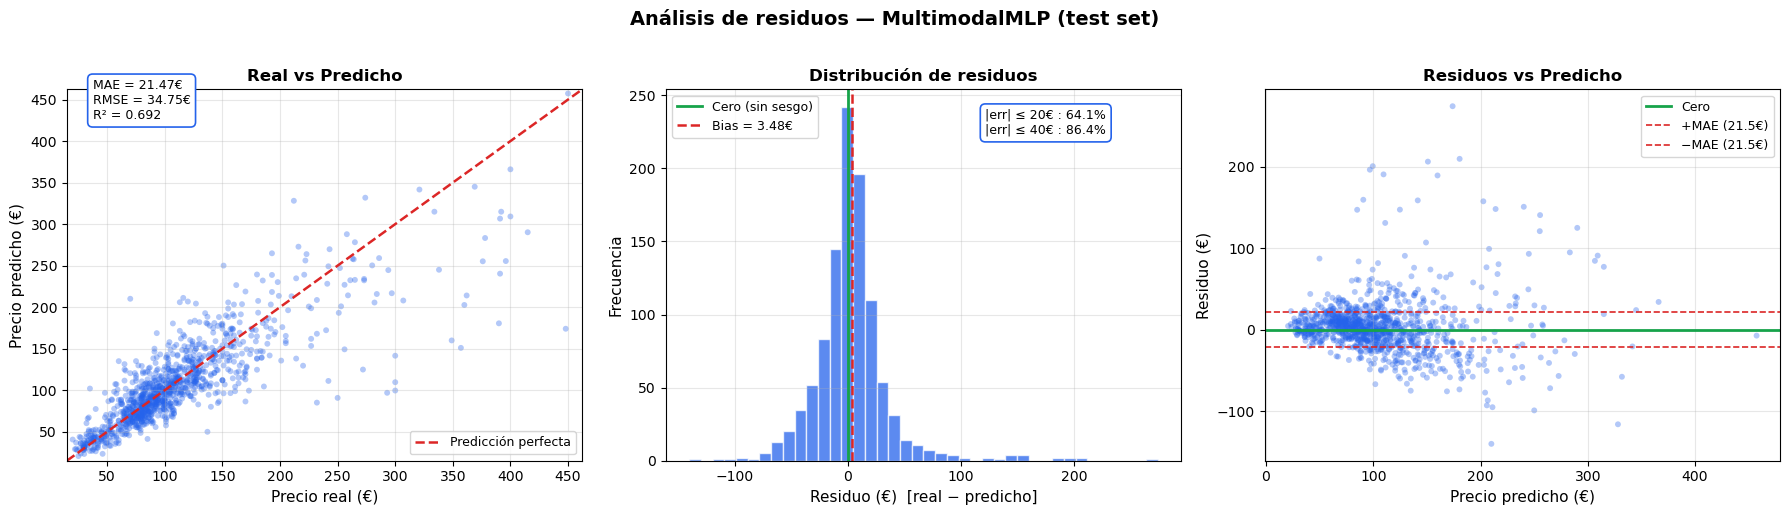

✅ Gráfica guardada en residual_analysis_multimodal.png


In [13]:
# ============================================================
# CELDA 13 — Análisis de residuos
# ============================================================

# ── Obtener predicciones sobre el test set ────────────────
model.eval()
all_preds, all_y = [], []

with torch.no_grad():
    for tab_b, vis_b, y_b in dl_test:
        tab_b, vis_b = tab_b.to(device), vis_b.to(device)
        preds = model(tab_b, vis_b).squeeze(1).cpu().numpy()
        all_preds.append(preds)
        all_y.append(y_b.numpy())

y_pred = np.concatenate(all_preds)   # (N_test,)
y_true = np.concatenate(all_y)       # (N_test,)
resid  = y_true - y_pred             # residuos: positivo = subestimación

# ── Métricas finales ──────────────────────────────────────
mae  = np.abs(resid).mean()
rmse = (resid ** 2).mean() ** 0.5
ss_res = (resid ** 2).sum()
ss_tot = ((y_true - y_true.mean()) ** 2).sum()
r2   = 1 - ss_res / ss_tot
bias = resid.mean()   # debería ser ≈ 0

print("=" * 55)
print("  MÉTRICAS FINALES — TEST SET")
print("=" * 55)
print(f"  MAE   : {mae:.2f} €")
print(f"  RMSE  : {rmse:.2f} €")
print(f"  R²    : {r2:.4f}")
print(f"  Bias  : {bias:.4f} €  (esperado ≈ 0)")
print(f"  N test: {len(y_true):,} muestras")

# ── Figura ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análisis de residuos — MultimodalMLP (test set)",
                fontsize=14, fontweight="bold", y=1.02)

C_SCATTER = "#2563EB"
C_HIST    = "#2563EB"
C_IDEAL   = "#DC2626"
C_ZERO    = "#16A34A"

# ── Panel 1: Real vs Predicho ─────────────────────────────
lim = (min(y_true.min(), y_pred.min()) - 5,
        max(y_true.max(), y_pred.max()) + 5)

axes[0].scatter(y_true, y_pred, alpha=0.35, s=18,
                color=C_SCATTER, edgecolors="none")
axes[0].plot(lim, lim, color=C_IDEAL, lw=1.8,
                linestyle="--", label="Predicción perfecta")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("Precio real (€)", fontsize=11)
axes[0].set_ylabel("Precio predicho (€)", fontsize=11)
axes[0].set_title("Real vs Predicho", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f"MAE = {mae:.2f}€\nRMSE = {rmse:.2f}€\nR² = {r2:.3f}",
                    xy=(0.05, 0.92), xycoords="axes fraction",
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.4", fc="white",
                            ec=C_SCATTER, lw=1.2))

# ── Panel 2: Histograma de residuos ──────────────────────
axes[1].hist(resid, bins=40, color=C_HIST, alpha=0.75, edgecolor="white")
axes[1].axvline(0,    color=C_ZERO,  lw=2,   linestyle="-",
                label="Cero (sin sesgo)")
axes[1].axvline(bias, color=C_IDEAL, lw=1.8, linestyle="--",
                label=f"Bias = {bias:.2f}€")
axes[1].set_xlabel("Residuo (€)  [real − predicho]", fontsize=11)
axes[1].set_ylabel("Frecuencia", fontsize=11)
axes[1].set_title("Distribución de residuos", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

pct_within_20 = (np.abs(resid) <= 20).mean() * 100
pct_within_40 = (np.abs(resid) <= 40).mean() * 100
axes[1].annotate(f"|err| ≤ 20€ : {pct_within_20:.1f}%\n"
                    f"|err| ≤ 40€ : {pct_within_40:.1f}%",
                    xy=(0.62, 0.88), xycoords="axes fraction",
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.4", fc="white",
                            ec=C_HIST, lw=1.2))

# ── Panel 3: Residuos vs Predicho (homocedasticidad) ─────
axes[2].scatter(y_pred, resid, alpha=0.35, s=18,
                color=C_SCATTER, edgecolors="none")
axes[2].axhline(0,    color=C_ZERO,  lw=2,   linestyle="-",  label="Cero")
axes[2].axhline(mae,  color=C_IDEAL, lw=1.2, linestyle="--", label=f"+MAE ({mae:.1f}€)")
axes[2].axhline(-mae, color=C_IDEAL, lw=1.2, linestyle="--", label=f"−MAE ({mae:.1f}€)")
axes[2].set_xlabel("Precio predicho (€)", fontsize=11)
axes[2].set_ylabel("Residuo (€)", fontsize=11)
axes[2].set_title("Residuos vs Predicho", fontsize=12, fontweight="bold")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("residual_analysis_multimodal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfica guardada en residual_analysis_multimodal.png")

## 14. Guardado del modelo para producción

In [14]:
# ============================================================
# CELDA 14 — Serializar modelo y artefactos para inferencia
# ============================================================
import json
import joblib
import pathlib
from datetime import datetime

ARTIFACTS_DIR = pathlib.Path("../models")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. Pesos del modelo (state_dict) ─────────────────────
# Preferible a torch.save(model) completo:
# más robusto ante cambios de ruta/clase entre entornos
MODEL_PATH = ARTIFACTS_DIR / "multimodal_mlp.pt"
torch.save(model.state_dict(), MODEL_PATH)

# ── 2. Scaler tabular ─────────────────────────────────────
# Ya guardado en celda 6, pero lo re-exportamos aquí
# para tener todos los artefactos juntos en /models
SCALER_PATH = ARTIFACTS_DIR / "scaler_tabular.pkl"
joblib.dump(scaler, SCALER_PATH)

# ── 3. Metadatos del modelo (JSON) ────────────────────────
# La API necesita conocer las dimensiones y columnas
# para reconstruir el modelo y escalar correctamente
metadata = {
    "created_at"    : datetime.now().isoformat(timespec="seconds"),
    "fusion_dim"    : FUSION_DIM,
    "tabular_dim"   : TABULAR_DIM,
    "visual_dim"    : VISUAL_DIM,
    "tabular_cols"  : cols_tabular,
    "target_col"    : TARGET_COL,
    "price_min"     : float(y.min()),
    "price_max"     : float(y.max()),
    "price_mean"    : float(y.mean()),
    "price_std"     : float(y.std()),
    "metrics": {
        "val_mae"   : round(float(min(history["va_mae"])), 4),
        "val_rmse"  : round(float(min(history["va_rmse"])), 4),
        "val_r2"    : round(float(history["r2"][best_ep - 1]), 4),
        "best_epoch": best_ep,
    },
}

META_PATH = ARTIFACTS_DIR / "multimodal_mlp_metadata.json"
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

# ── 4. Verificación: carga y forward pass de prueba ──────
model_check = MultimodalMLP(fusion_dim=FUSION_DIM).to(device)
model_check.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model_check.eval()

with torch.no_grad():
    tab_dummy = torch.zeros(1, TABULAR_DIM, device=device)
    vis_dummy = torch.zeros(1, VISUAL_DIM,  device=device)
    out = model_check(tab_dummy, vis_dummy)

assert out.shape == (1, 1), "❌ Forward pass de verificación falló"

# ── Resumen ───────────────────────────────────────────────
print("=" * 55)
print("  ARTEFACTOS GUARDADOS")
print("=" * 55)
print(f"  📦 Pesos del modelo  : {MODEL_PATH.resolve()}")
print(f"     Tamaño            : {MODEL_PATH.stat().st_size / 1024:.1f} KB")
print()
print(f"  📦 Scaler tabular    : {SCALER_PATH.resolve()}")
print(f"     Tamaño            : {SCALER_PATH.stat().st_size / 1024:.1f} KB")
print()
print(f"  📦 Metadatos JSON    : {META_PATH.resolve()}")
print(f"     Tamaño            : {META_PATH.stat().st_size / 1024:.1f} KB")
print()
print("  🔍 Verificación de carga:")
print(f"     Forward pass OK   : input (1,{TABULAR_DIM}) + (1,{VISUAL_DIM})"
     f" → output {tuple(out.shape)} ✅")
print()
print("  📋 Metadatos registrados:")
print(f"     Creado            : {metadata['created_at']}")
print(f"     FUSION_DIM        : {metadata['fusion_dim']}")
print(f"     Columnas tabulares: {metadata['tabular_dim']}")
print(f"     Val MAE           : {metadata['metrics']['val_mae']} €")
print(f"     Val R²            : {metadata['metrics']['val_r2']}")
print(f"     Mejor época       : {metadata['metrics']['best_epoch']}")

  ARTEFACTOS GUARDADOS
  📦 Pesos del modelo  : C:\Users\david\Desktop\ESP. IA - BD\PIA\TRABAJO_AIRBNB\SmartHost-Analytics\models\multimodal_mlp.pt
     Tamaño            : 699.9 KB

  📦 Scaler tabular    : C:\Users\david\Desktop\ESP. IA - BD\PIA\TRABAJO_AIRBNB\SmartHost-Analytics\models\scaler_tabular.pkl
     Tamaño            : 1.3 KB

  📦 Metadatos JSON    : C:\Users\david\Desktop\ESP. IA - BD\PIA\TRABAJO_AIRBNB\SmartHost-Analytics\models\multimodal_mlp_metadata.json
     Tamaño            : 1.1 KB

  🔍 Verificación de carga:
     Forward pass OK   : input (1,30) + (1,512) → output (1, 1) ✅

  📋 Metadatos registrados:
     Creado            : 2026-04-27T12:50:33
     FUSION_DIM        : 542
     Columnas tabulares: 30
     Val MAE           : 21.4747 €
     Val R²            : 0.6922
     Mejor época       : 35


C:\Users\david\AppData\Local\Temp\ipykernel_31352\2266005068.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_check.load_state_dict(torch.load(MODEL_PATH, map_loca